### **0. Datos de estudiantes**

María Daniela Rodríguez Chacón

mdaniela.rodriguez@udea.edu.co

David Agudelo Ochoa

david.agudeloo@udea.edu.co

### **1. Definición del proyecto**













#### **Planteamiento del problema**
¿Qué perfiles de pacientes diabéticos hospitalizados pueden identificarse a partir de sus características demográficas, clínicas y de uso de servicios de salud?

#### **Objetivo general**

Caracterizar los perfiles de pacientes diabéticos hospitalizados mediante el análisis exploratorio de sus variables demográficas, clínicas y de uso hospitalario, con el fin de identificar patrones relevantes en su comportamiento.

#### **Objetivos específicos**

*   Analizar la distribución de las variables demográficas y clínicas de los pacientes.
*   Identificar relaciones entre variables como tiempo de hospitalización, número de medicamentos y uso previo de servicios.
*   Detectar valores atípicos y evaluar su impacto en el análisis.
*   Aplicar técnicas de reducción de dimensionalidad o agrupamiento para identificar perfiles de pacientes.
*   Interpretar los patrones encontrados desde una perspectiva clínica y operativa.

#### **Justificación del enfoque metodológico**

El presente proyecto adopta un enfoque **exploratorio no supervisado**, dado que la pregunta analítica no postula una variable de respuesta conocida, sino que busca descubrir estructura latente en los datos. Esto descarta los enfoques supervisados como alternativa principal y justifica la siguiente ruta metodológica:

| Fase | Técnica | Justificación |
|------|---------|---------------|
| Análisis univariado y bivariado | Estadística descriptiva, histogramas, boxplots, matrices de correlación | Comprensión inicial de distribuciones y relaciones entre variables |
| Detección de atípicos | IQR, Z-score, Isolation Forest | Identificación de casos anómalos antes del preprocesamiento |
| Imputación y transformación | Imputación por moda/categoría, codificación ordinal, StandardScaler | Preparación de datos con calidad analítica para clustering |
| Reducción de dimensionalidad | PCA (9 componentes, ≥80% varianza explicada) | Eliminación de redundancia entre las 12 variables seleccionadas |
| Identificación de perfiles | K-Means (k=2, silueta=0.1558) | Partición eficiente de los 101.766 registros en grupos coherentes |

El dataset seleccionado es adecuado para este enfoque por su tamaño (>100.000 registros), su diversidad de tipos de variables (numéricas y categóricas) y su riqueza clínica, que permite obtener perfiles con significado operativo real.

### **2. Selección de la base de datos**

**Url dataset:**

[Diabetes 130-US Hospitals Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

El conjunto de datos seleccionado corresponde a registros de pacientes diabéticos hospitalizados durante un periodo de diez años (1999–2008), incluyendo información clínica, demográfica y de uso de servicios de salud.
Este dataset es adecuado para el análisis propuesto debido a que:

*   Contiene 101766 registros, lo que permite identificar patrones significativos.
*   Incluye 50 variables relevantes como edad, género, número de medicamentos y tiempo de hospitalización.
*   Presenta diferentes tipos de datos (numéricos y categóricos), lo que facilita un análisis exploratorio completo.
*   Tiene una estructura clara donde cada fila representa un paciente y cada columna una variable.


Además, el dataset permite responder la pregunta de investigación mediante variables demográficas como `age`, `race` y `gender`; variables clínicas como `time_in_hospital`, `num_medications`, `number_diagnoses`, `A1Cresult` y `diabetesMed`; y variables relacionadas con el uso de servicios hospitalarios como `number_inpatient`, `number_outpatient` y `number_emergency`, las cuales facilitan la identificación de patrones de complejidad clínica, frecuencia de hospitalización y comportamiento asistencial de los pacientes diabéticos. Sin embargo, una limitación inicial del conjunto de datos es la presencia de valores faltantes y variables categóricas con alta dispersión, lo que requiere procesos de limpieza, imputación y transformación.

#### **Descripción detallada**

El dataset corresponde al **Diabetes 130-US Hospitals Dataset** (Strack et al., 2014), disponible en el repositorio UCI Machine Learning Repository. Cada fila representa un **encuentro hospitalario único** de un paciente diabético.

| Dimensión | Valor |
|-----------|-------|
| Registros | 101.766 |
| Variables | 50 |
| Periodo | 1999–2008 |
| Hospitales | 130 (EE. UU.) |
| Unidad de observación | Encuentro hospitalario |

Las variables se agrupan en cuatro categorías:

- **Demográficas**: `race`, `gender`, `age`
- **Clínicas**: `diag_1/2/3` (ICD-9), `max_glu_serum`, `A1Cresult`, 23 variables de medicamentos antidiabéticos
- **Uso hospitalario**: `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`
- **Historial de servicios**: `number_outpatient`, `number_emergency`, `number_inpatient`, `readmitted`

> **Nota sobre valores faltantes**: el dataset codifica los valores ausentes con el símbolo `?`, que debe reemplazarse por `NaN` antes del análisis. Las variables `weight` (96.8% ausente), `max_glu_serum` (94.7%) y `A1Cresult` (83.3%) presentan tasas de omisión muy elevadas que condicionan su uso analítico.












**Librerías necesarias**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

### **3. Descripción del conjunto de datos**

**Estrutura del dataset seleccionado**

In [ ]:
df = pd.read_csv('/content/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Número de registros y variables**

In [ ]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 101766
Número de variables: 50


**Tipos de datos por variable**

In [ ]:
print(df.dtypes.value_counts())

object    37
int64     13
Name: count, dtype: int64


**Clasificación de variables**

In [ ]:
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:")
print("\n".join([f"* {col}" for col in categoricas]))

print("\nVariables numéricas:")
print("\n".join([f"* {col}" for col in numericas]))

Variables categóricas:
* race
* gender
* age
* weight
* payer_code
* medical_specialty
* diag_1
* diag_2
* diag_3
* max_glu_serum
* A1Cresult
* metformin
* repaglinide
* nateglinide
* chlorpropamide
* glimepiride
* acetohexamide
* glipizide
* glyburide
* tolbutamide
* pioglitazone
* rosiglitazone
* acarbose
* miglitol
* troglitazone
* tolazamide
* examide
* citoglipton
* insulin
* glyburide-metformin
* glipizide-metformin
* glimepiride-pioglitazone
* metformin-rosiglitazone
* metformin-pioglitazone
* change
* diabetesMed
* readmitted

Variables numéricas:
* encounter_id
* patient_nbr
* admission_type_id
* discharge_disposition_id
* admission_source_id
* time_in_hospital
* num_lab_procedures
* num_procedures
* num_medications
* number_outpatient
* number_emergency
* number_inpatient
* number_diagnoses


**Descripción de variables numéricas**

In [ ]:
print(df.describe())

       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             7.00000

**Valores faltantes**

El dataset representa los valores faltantes con un símbolo `?`. Por eso, reemplazamos el símbolo por `NaN`

In [ ]:
df.replace('?', np.nan, inplace=True)

faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])


Conteo de valores faltantes por variable:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


#### **Variables más importantes para el problema planteado**

In [ ]:
variables_demograficas = ['race','gender','age','time_in_hospital','number_inpatient',
                          'number_outpatient','number_emergency', 'readmitted','num_medications',
                          'num_lab_procedures','diag_1','diag_2', 'diag_3']
print("\nVista rápida de variables clave (demográficas):")
print(df[variables_demograficas].head())
# Vista rápida de las variables clave
print("\nEstadísticas descriptivas de variables clave(demográficas):")
print(df[variables_demograficas].describe())


Vista rápida de variables clave (demográficas):
              race  gender      age  time_in_hospital  number_inpatient  \
0        Caucasian  Female   [0-10)                 1                 0   
1        Caucasian  Female  [10-20)                 3                 0   
2  AfricanAmerican  Female  [20-30)                 2                 1   
3        Caucasian    Male  [30-40)                 2                 0   
4        Caucasian    Male  [40-50)                 1                 0   

   number_outpatient  number_emergency readmitted  num_medications  \
0                  0                 0         NO                1   
1                  0                 0        >30               18   
2                  2                 0         NO               13   
3                  0                 0         NO               16   
4                  0                 0         NO                8   

   num_lab_procedures  diag_1  diag_2 diag_3  
0                  41  250.83   

Se seleccionaron estas variables porque permiten construir una caracterización integral de los pacientes diabéticos hospitalizados, alineada con la pregunta de investigación sobre la identificación de perfiles a partir de características demográficas, clínicas y de uso de servicios de salud. Las variables demográficas (`age`, `gender`, `race`) describen el perfil poblacional del paciente y permiten analizar posibles diferencias entre grupos en términos de comportamiento clínico y utilización del sistema de salud. Las variables relacionadas con el uso de servicios (`time_in_hospital`, `number_inpatient`, `number_outpatient`, `number_emergency`, `readmitted`) capturan la intensidad y frecuencia de interacción con el sistema sanitario, lo que ayuda a identificar patrones como alta utilización de servicios o riesgo de reingreso. Finalmente, las variables clínicas (`num_medications`, `num_lab_procedures`, `diag_1`, `diag_2`, `diag_3`) reflejan la complejidad médica del paciente, incluyendo comorbilidades, carga terapéutica e intensidad diagnóstica. En conjunto, estas variables permiten integrar las tres dimensiones fundamentales del problema (demográfica, clínica y de utilización de servicios), facilitando la construcción de perfiles interpretables de pacientes dentro del dataset.

### **4. Análisis exploratorio de datos (EDA)**

In [ ]:
#Colores para nuestras gráficas
colors = ["#aadff9", "#86b5d3", "#638bae", "#3f6088", "#1b3662"]
sns.set_palette(colors)

#### **Análisis Univariado**

**Distribución de variables numéricas**

**Medidas de tendencia central**

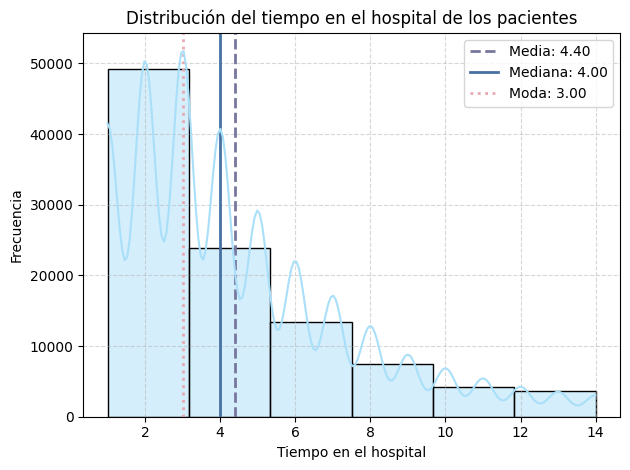

In [ ]:
media = np.mean(df['time_in_hospital'])
mediana = np.median(df['time_in_hospital'])
moda = stats.mode(df['time_in_hospital'], keepdims=True)[0][0]

plt.axvline(media, color='#77779d', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='#4771a3', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='#e7a8b1', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')


sns.histplot(df['time_in_hospital'], bins=6, kde=True)
plt.title("Distribución del tiempo en el hospital de los pacientes")
plt.xlabel("Tiempo en el hospital")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_tiempo_hospital.png',
            dpi=150,
            bbox_inches='tight')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

**Medidas de distribución**

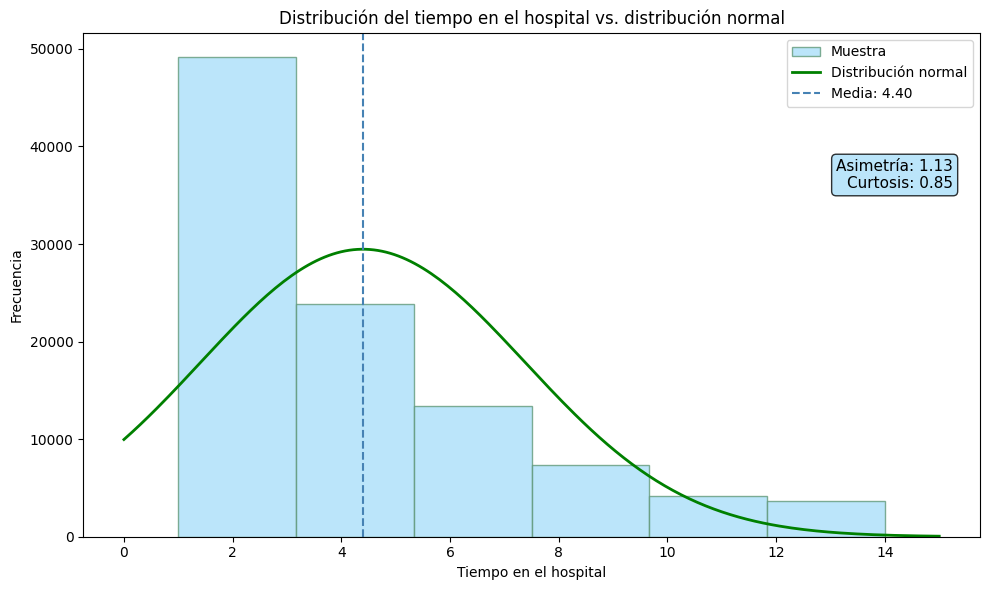

In [ ]:
datos = df['time_in_hospital']

media = datos.mean()
desviacion_estandar = datos.std()
asimetria = stats.skew(datos)
curtosis = stats.kurtosis(datos)
tamano_muestra = len(datos)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    datos,
    bins=6,
    density=False,
    color=colors[0],
    edgecolor="#62997a",
    alpha=0.8,
    label='Muestra'
)

x = np.linspace(datos.min() - 1, datos.max() + 1, 200)

pdf = stats.norm.pdf(x, media, desviacion_estandar)

ax.plot(
    x,
    pdf * tamano_muestra * (datos.max() - datos.min()) / 6,
    color='green',
    linewidth=2,
    label='Distribución normal'
)

ax.axvline(
    media,
    color='steelblue',
    linestyle='--',
    linewidth=1.5,
    label=f'Media: {media:.2f}'
)

textstr = f'Asimetría: {asimetria:.2f}\nCurtosis: {curtosis:.2f}'

ax.text(
    0.97,
    0.75,
    textstr,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor= colors[0], alpha=0.8)
)

ax.set_title('Distribución del tiempo en el hospital vs. distribución normal')
ax.set_xlabel('Tiempo en el hospital')
ax.set_ylabel('Frecuencia')

ax.legend()
plt.tight_layout()

plt.savefig(
    '/content/1.dist_tiempo_hospital.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

La distribución del tiempo de hospitalización está fuertemente sesgada a la derecha, con la mayoría de pacientes concentrados en estancias cortas (1–3 días).
A medida que aumenta el tiempo de estancia, la frecuencia de pacientes disminuye de forma progresiva, lo que indica pocos casos de hospitalizaciones prolongadas.
Esto sugiere que la mayoría de ingresos son de baja complejidad o resolución rápida.

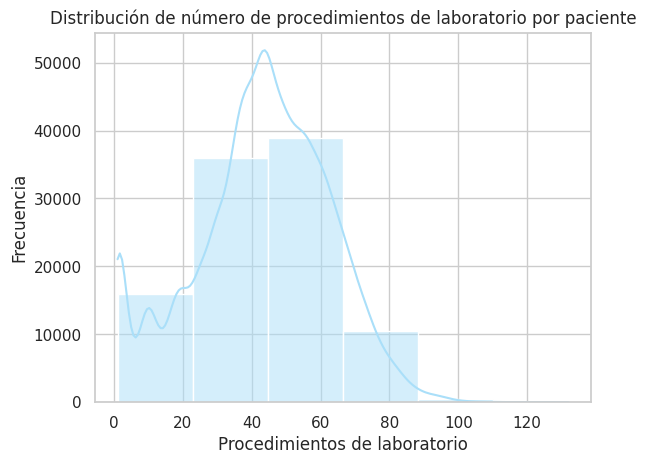

In [ ]:
sns.histplot(df['num_lab_procedures'], bins=6, kde=True)
plt.title("Distribución de número de procedimientos de laboratorio por paciente")
plt.xlabel("Procedimientos de laboratorio")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_lab_procedimientos.png', dpi=150, bbox_inches='tight')
plt.show()

La distribución del número de procedimientos de laboratorio es aproximadamente normal, con mayor concentración entre 30 y 60 procedimientos por paciente.
Se observa que muy pocos pacientes tienen valores extremos (muy bajos o superiores a 80–100), lo que sugiere cierta homogeneidad en la intensidad diagnóstica.

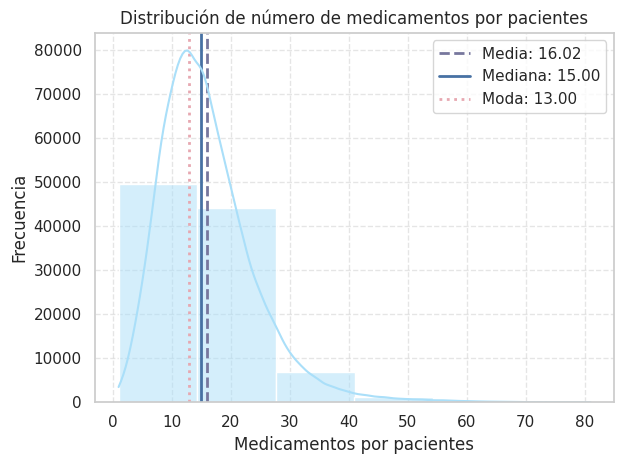

In [ ]:
media = np.mean(df['num_medications'])
mediana = np.median(df['num_medications'])
moda = df['num_medications'].mode()[0]

plt.axvline(media, color='#77779d', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='#4771a3', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='#e7a8b1', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')


sns.histplot(df['num_medications'], bins=6, kde=True)
plt.title("Distribución de número de medicamentos por pacientes")
plt.xlabel("Medicamentos por pacientes")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_med_pacientes.png', dpi=150, bbox_inches='tight')


plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

La distribución del número de medicamentos por paciente está concentrada principalmente entre 5 y 20 fármacos, con un pico alrededor de ese rango.
Se observa una cola hacia la derecha, indicando que pocos pacientes reciben un número muy alto de medicamentos.

**Distribución variables categóricas**

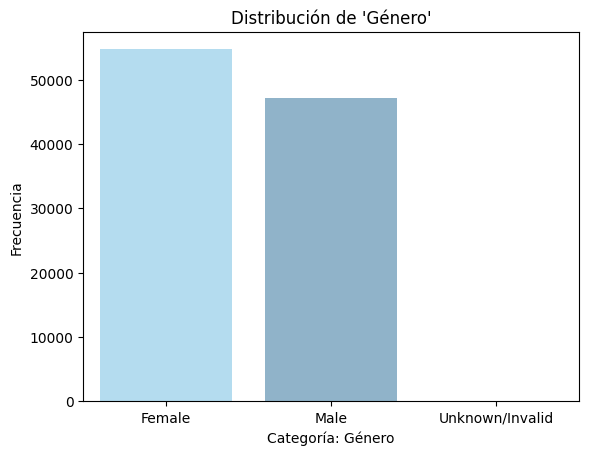

In [ ]:
sns.countplot(x='gender', data=df, hue='gender', palette=colors[0:3],legend=False)
plt.title("Distribución de 'Género'")
plt.xlabel("Categoría: Género")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_genero.png', dpi=150, bbox_inches='tight')
plt.show()

La distribución de género está relativamente equilibrada, aunque hay más registros de pacientes femeninos. La categoría “Unknown/Invalid” es prácticamente inexistente, lo que sugiere buena calidad en esta variable.

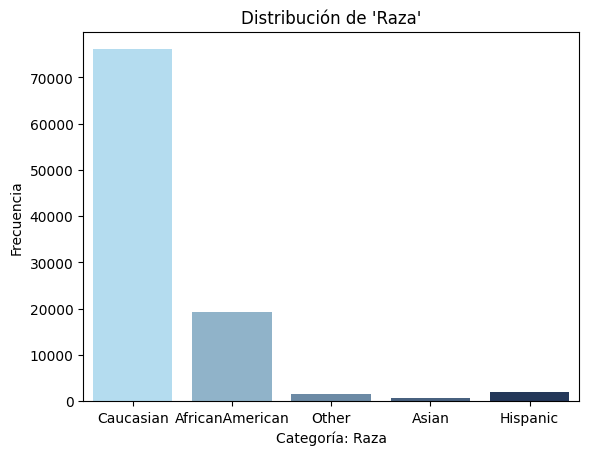

In [ ]:
sns.countplot(x='race', data=df, hue='race', palette=colors,legend=False)
plt.title("Distribución de 'Raza'")
plt.xlabel("Categoría: Raza")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_raza.png', dpi=150, bbox_inches='tight')
plt.show()

La mayoría de los registros corresponden a pacientes caucásicos (`Caucasian`), seguidos a gran distancia por pacientes afroamericanos (`AfricanAmerican`).
Las demás categorías raciales (`Hispanic`, `Other` y `Asian`) tienen una representación mucho menor, mostrando un claro desbalance en la distribución.

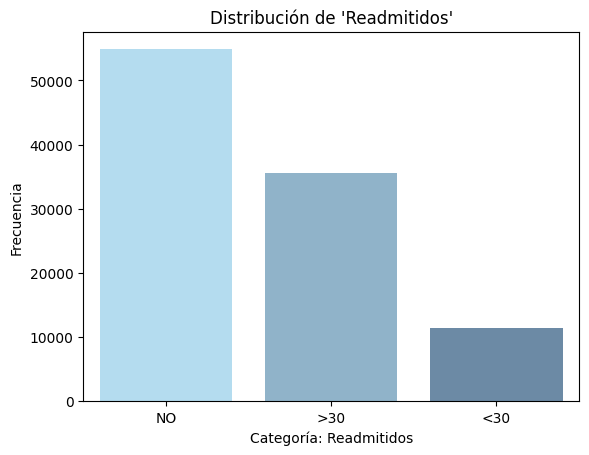

In [ ]:
sns.countplot(x='readmitted', data=df, hue='readmitted', palette=colors[0:3],legend=False)
plt.title("Distribución de 'Readmitidos'")
plt.xlabel("Categoría: Readmitidos")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_readmitidos.png', dpi=150, bbox_inches='tight')
plt.show()

La mayoría de los pacientes no fueron readmitidos (`NO`), mientras que una proporción importante sí tuvo readmisiones después de 30 días (`>30`).
Las readmisiones en menos de 30 días (`<30`) aunque son las menos frecuentes, representan un grupo relevante.

#### **Boxplot para detección de outliers**

In [ ]:
numeric_cols = ['time_in_hospital', 'num_medications','num_lab_procedures']

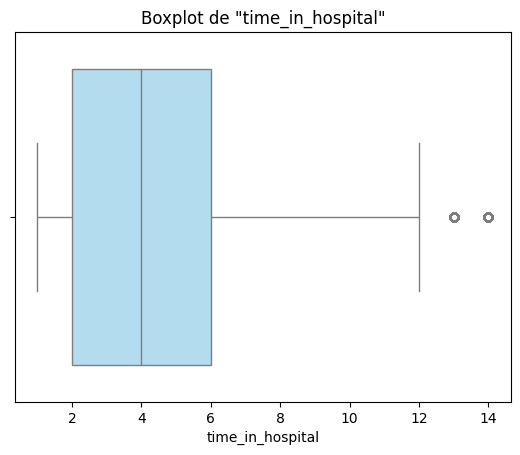

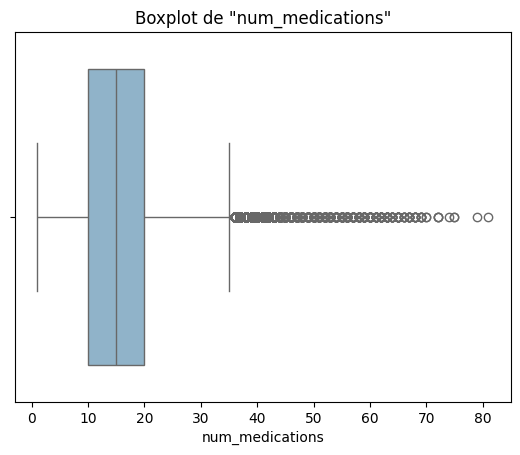

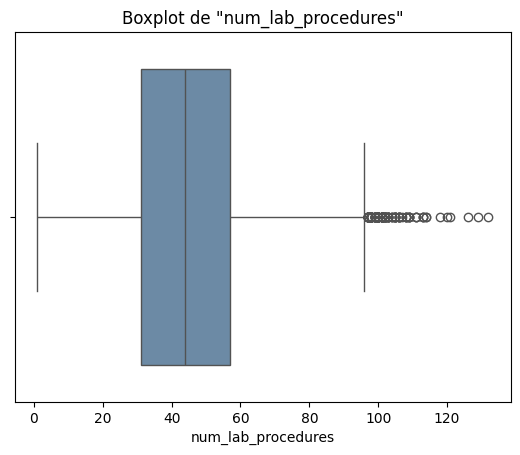

In [ ]:
for i, col in enumerate(numeric_cols):
    plt.figure()
    sns.boxplot(x=df[col].astype(float), color=colors[i % len(colors)])
    plt.title(f'Boxplot de "{col}"')
    plt.savefig('/content/1.box_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()

* `time_in_hospital` muestra una distribución moderadamente asimétrica a la derecha: la mayoría de pacientes permanece entre 2 y 6 días, con pocos casos extremos de estancias largas (13–14 días).
* `num_medications` presenta fuerte asimetría positiva y numerosos outliers, indicando que algunos pacientes reciben una cantidad excepcionalmente alta de medicamentos.
* `num_lab_procedures` también está sesgada a la derecha, aunque con mayor dispersión central; la mayoría de observaciones se concentra alrededor de 30–60 procedimientos.


### **5. Aplicación de técnicas de análisis univariado, bivariado y multivariado**

### Análisis bivariado

/tmp/ipykernel_8215/2623735701.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df,


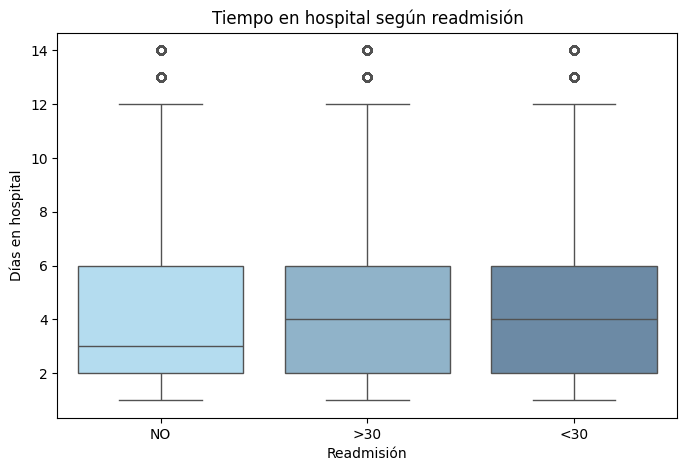

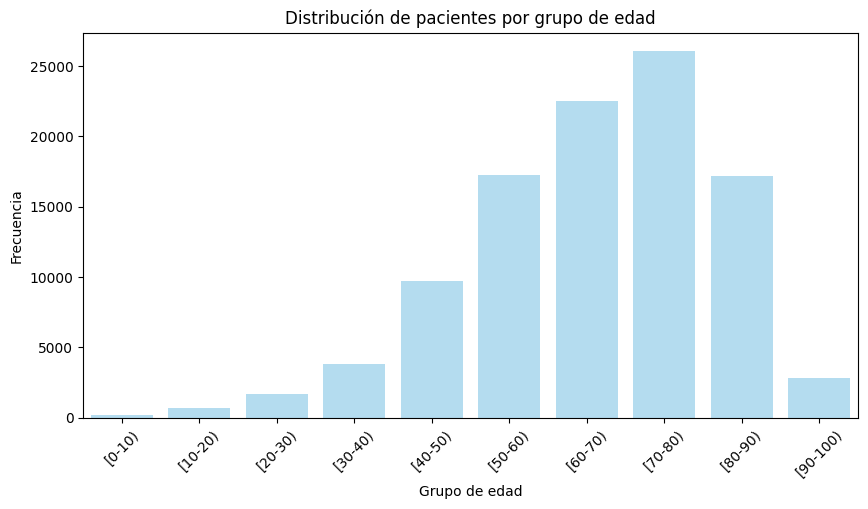

/tmp/ipykernel_8215/2623735701.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='readmitted', y='num_medications', data=df,


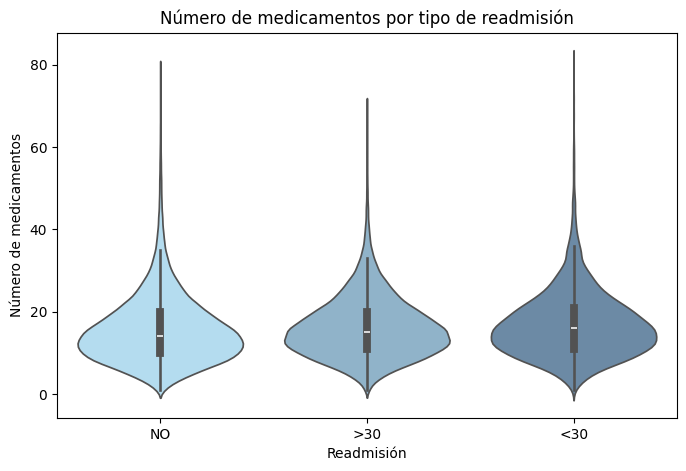

In [ ]:
# 1. Tiempo en hospital por readmisión
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df,
            palette=colors[:3], order=['NO', '>30', '<30'])
plt.title('Tiempo en hospital según readmisión')
plt.xlabel('Readmisión')
plt.ylabel('Días en hospital')
plt.savefig('/content/2.biv_tiempo_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Distribución de edad (variable categórica ordinal)
orden_edad = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
plt.figure(figsize=(10, 5))
sns.countplot(x='age', data=df, order=orden_edad)
plt.title('Distribución de pacientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.savefig('/content/2.biv_edad.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Número de medicamentos por readmisión
plt.figure(figsize=(8, 5))
sns.violinplot(x='readmitted', y='num_medications', data=df,
               palette=colors[:3], order=['NO', '>30', '<30'])
plt.title('Número de medicamentos por tipo de readmisión')
plt.xlabel('Readmisión')
plt.ylabel('Número de medicamentos')
plt.savefig('/content/2.biv_med_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis multivariado

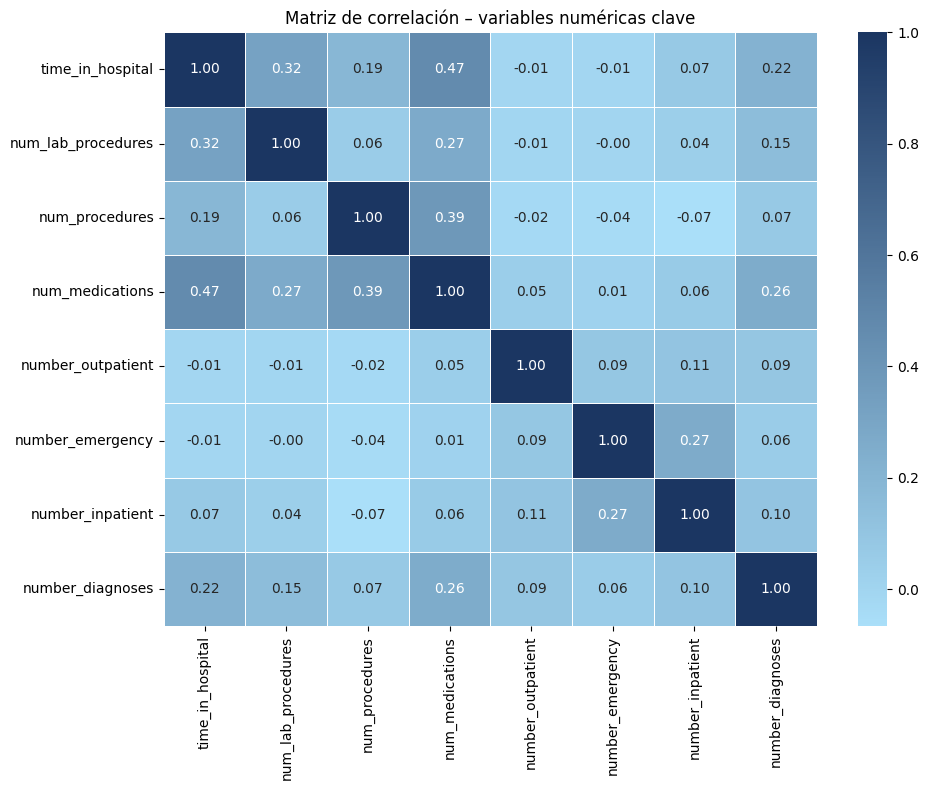

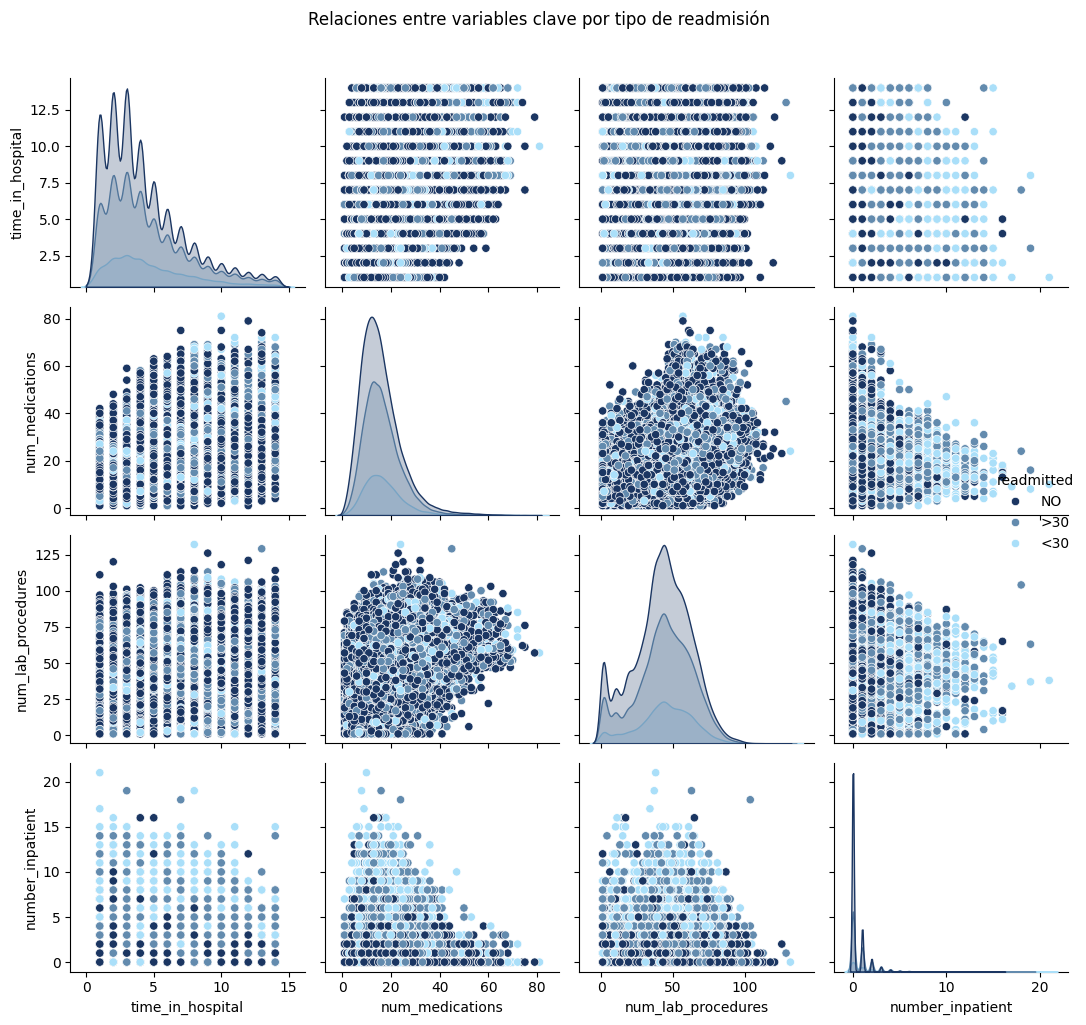

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

num_cols_completo = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

plt.figure(figsize=(10, 8))

corr = df[num_cols_completo].astype(float).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    linewidths=0.5
)

plt.title('Matriz de correlación – variables numéricas clave')

plt.tight_layout()

plt.savefig('/content/2.multi_corr_ampliada.png',
            dpi=150,
            bbox_inches='tight')

plt.show()


pairplot_vars = [
    'time_in_hospital',
    'num_medications',
    'num_lab_procedures',
    'number_inpatient',
    'readmitted'
]

g = sns.pairplot(
    df[pairplot_vars].dropna(),
    hue='readmitted',
    palette={
        'NO': '#1b3662',
        '>30': '#638bae',
        '<30': '#aadff9'
    }
)

g.fig.suptitle(
    'Relaciones entre variables clave por tipo de readmisión',
    y=1.02
)

# Ajustar espacio superior
g.fig.tight_layout()

# Guardar usando la figura del pairplot
g.fig.savefig(
    '/content/2.multi_pairplot.png',
            dpi=150,
            bbox_inches='tight')

plt.show()
plt.close()
plt.show()

### **5. Detección y tratamiento de datos atípicos**

La detección de valores atípicos (outliers) es una etapa crítica antes del preprocesamiento. Un outlier puede ser:
- **Error de captura**: dato incoherente con el dominio clínico.
- **Caso clínico real pero infrecuente**: paciente con condiciones especialmente complejas.

Se aplican tres enfoques complementarios: **método IQR** (estadístico), **Z-score** (paramétrico) y **Isolation Forest** (aprendizaje automático).

Detección de outliers — Método IQR:
          Variable   Q1   Q3  IQR  Límite inf.  Límite sup.  N outliers  % outliers
  time_in_hospital  2.0  6.0  4.0         -4.0         12.0        2252        2.21
   num_medications 10.0 20.0 10.0         -5.0         35.0        2557        2.51
num_lab_procedures 31.0 57.0 26.0         -8.0         96.0         143        0.14
    num_procedures  0.0  2.0  2.0         -3.0          5.0        4954        4.87
  number_inpatient  0.0  1.0  1.0         -1.5          2.5        7049        6.93
  number_emergency  0.0  0.0  0.0          0.0          0.0       11383       11.19
 number_outpatient  0.0  0.0  0.0          0.0          0.0       16739       16.45
  number_diagnoses  6.0  9.0  3.0          1.5         13.5         281        0.28


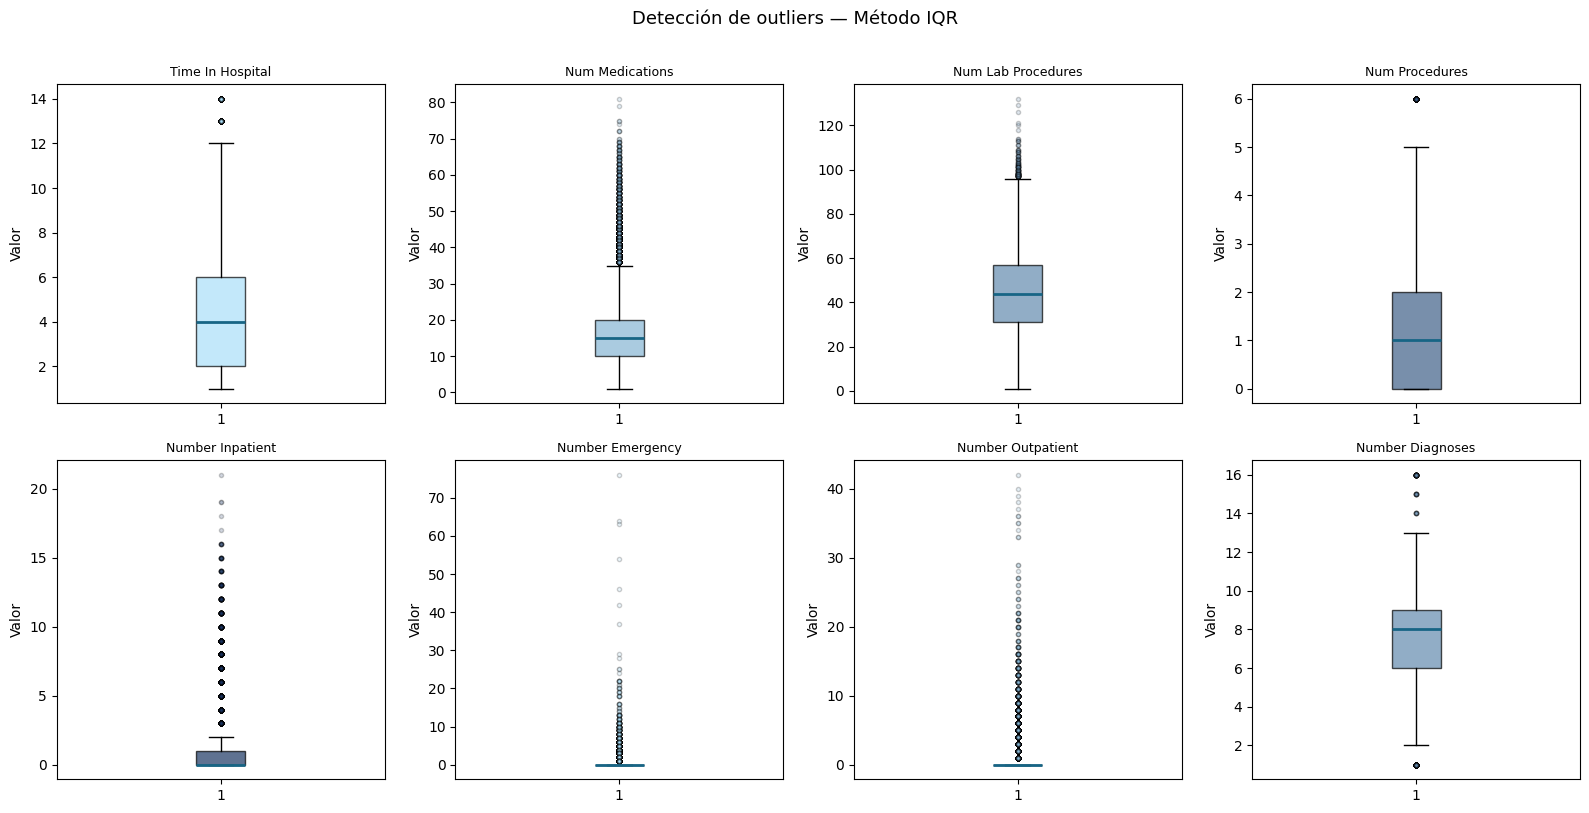

In [ ]:
# Método IQR

colors = ("#aadff9", "#86b5d3", "#638bae", "#3f6088", "#1b3662")

# Variables numéricas de interés clínico
outlier_vars = ['time_in_hospital', 'num_medications', 'num_lab_procedures',
                'num_procedures', 'number_inpatient', 'number_emergency',
                'number_outpatient', 'number_diagnoses']

# Cálculo de límites IQR y conteo de outliers
resultados_iqr = []
for col in outlier_vars:
    serie = df[col].astype(float).dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    pct = n_outliers / len(serie) * 100
    resultados_iqr.append({
        'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Límite inf.': round(limite_inf, 2),
        'Límite sup.': round(limite_sup, 2),
        'N outliers': n_outliers, '% outliers': round(pct, 2)
    })

df_iqr = pd.DataFrame(resultados_iqr)
print('Detección de outliers — Método IQR:')
print(df_iqr.to_string(index=False))

# Boxplots ampliados
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col, color in zip(axes.flatten(), outlier_vars, colors * 2):
    ax.boxplot(df[col].astype(float).dropna(), vert=True,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='#176585', linewidth=2),
               flierprops=dict(marker='o', alpha=0.2,
                               markerfacecolor=color, markersize=3))
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Valor')
plt.suptitle('Detección de outliers — Método IQR', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/3.outliers_iqr_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Detección de outliers — Método Z-score (umbral |z| > 3):
          Variable  Media  Desv. Std.  N outliers (|z|>3)  % outliers
  time_in_hospital   4.40        2.99                1042        1.02
   num_medications  16.02        8.13                1361        1.34
num_lab_procedures  43.10       19.67                  43        0.04
    num_procedures   1.34        1.71                   0        0.00
  number_inpatient   0.64        1.26                2016        1.98
  number_emergency   0.20        0.93                1664        1.64
 number_outpatient   0.37        1.27                1457        1.43
  number_diagnoses   7.42        1.93                 281        0.28


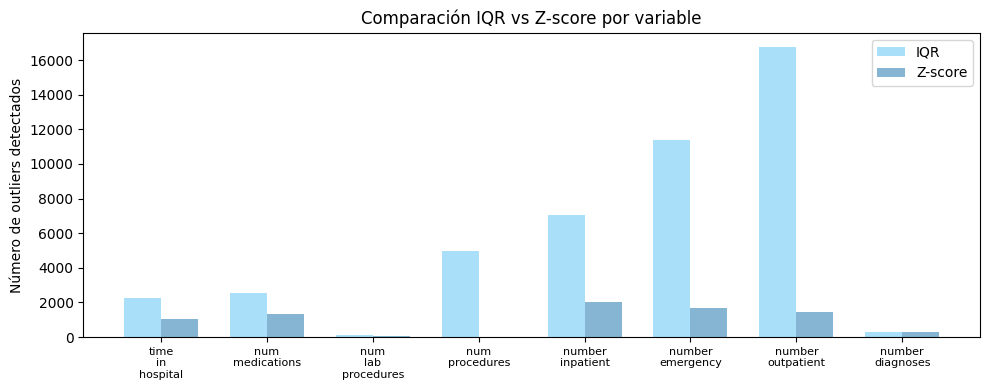

In [ ]:
#Z-score

from scipy import stats

resultados_z = []
for col in outlier_vars:
    serie = df[col].astype(float).dropna()
    z_scores = np.abs(stats.zscore(serie))
    n_outliers_z = (z_scores > 3).sum()
    pct_z = n_outliers_z / len(serie) * 100
    resultados_z.append({
        'Variable': col,
        'Media': round(serie.mean(), 2),
        'Desv. Std.': round(serie.std(), 2),
        'N outliers (|z|>3)': n_outliers_z,
        '% outliers': round(pct_z, 2)
    })

df_z = pd.DataFrame(resultados_z)
print('Detección de outliers — Método Z-score (umbral |z| > 3):')
print(df_z.to_string(index=False))

# Comparación IQR vs Z-score
comparacion = df_iqr[['Variable', 'N outliers']].rename(
    columns={'N outliers': 'IQR'}).merge(
    df_z[['Variable', 'N outliers (|z|>3)']].rename(
        columns={'N outliers (|z|>3)': 'Z-score'}), on='Variable')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparacion))
width = 0.35
ax.bar(x - width/2, comparacion['IQR'], width, label='IQR')
ax.bar(x + width/2, comparacion['Z-score'], width, label='Z-score')
ax.set_xticks(x)
ax.set_xticklabels([v.replace('_', '\n') for v in comparacion['Variable']], fontsize=8)
ax.set_ylabel('Número de outliers detectados')
ax.set_title('Comparación IQR vs Z-score por variable')
ax.legend()
plt.tight_layout()
plt.savefig('/content/3.outliers_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

Isolation Forest — Resultados:
  Registros normales : 96,677 (95.0%)
  Registros anómalos : 5,089 (5.0%)

Media por grupo (Normal vs Anómalo):
tipo                Anómalo  Normal
time_in_hospital       6.61    4.28
num_medications       24.34   15.58
num_lab_procedures    46.80   42.90
num_procedures         2.57    1.27
number_inpatient       2.49    0.54
number_emergency       1.78    0.11
number_outpatient      2.21    0.27
number_diagnoses       7.59    7.41


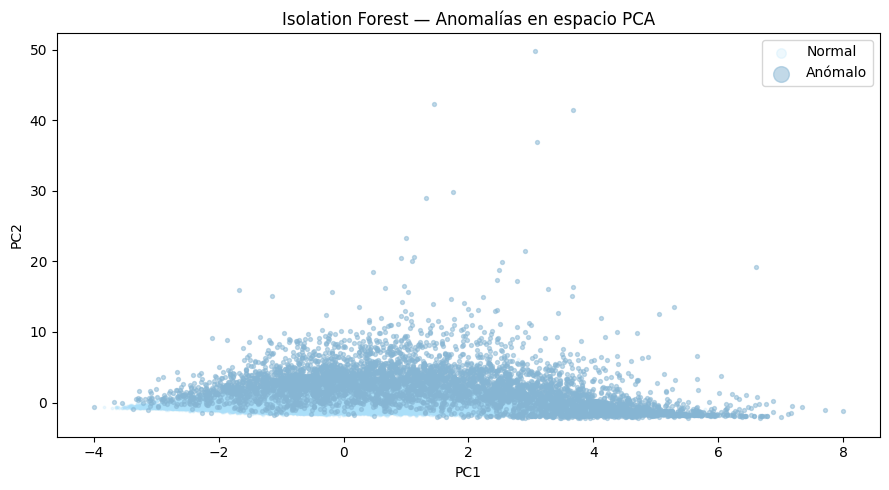

In [ ]:
#Isolation forest

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA as PCA_tmp

# contamination=0.05 asume que ~5% de los registros son atípicos
X_outlier = df[outlier_vars].astype(float).dropna()

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
predicciones = iso.fit_predict(X_outlier)

n_anomalos = (predicciones == -1).sum()
pct_anomalos = n_anomalos / len(predicciones) * 100
print(f'Isolation Forest — Resultados:')
print(f'  Registros normales : {(predicciones==1).sum():,} ({100-pct_anomalos:.1f}%)')
print(f'  Registros anómalos : {n_anomalos:,} ({pct_anomalos:.1f}%)')

# Comparar medias por grupo
X_copy = X_outlier.copy()
X_copy['tipo'] = np.where(predicciones == -1, 'Anómalo', 'Normal')
print('\nMedia por grupo (Normal vs Anómalo):')
print(X_copy.groupby('tipo')[outlier_vars].mean().round(2).T.to_string())

# Visualización en espacio PCA 2D
X_2d = PCA_tmp(n_components=2).fit_transform(
    (X_outlier - X_outlier.mean()) / X_outlier.std())
plt.figure(figsize=(9, 5))
plt.scatter(X_2d[predicciones==1,0], X_2d[predicciones==1,1],
            s=3, alpha=0.2, label='Normal')
plt.scatter(X_2d[predicciones==-1,0], X_2d[predicciones==-1,1],
            s=8, alpha=0.5, label='Anómalo')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Isolation Forest — Anomalías en espacio PCA')
plt.legend(markerscale=4)
plt.tight_layout()
plt.savefig('/content/3.outliers_iforest.png', dpi=150, bbox_inches='tight')
plt.show()

**Decisión sobre el tratamiento de outliers**

| Variable | % outliers (IQR) | Decisión | Justificación |
|----------|:----------------:|----------|---------------|
| `time_in_hospital` | Bajo | **Conservar** | Rango 1–14 días definido por el dominio; extremos son clínicamente válidos |
| `num_medications` | Moderado | **Conservar** | Casos con alta medicación representan pacientes de mayor complejidad |
| `num_lab_procedures` | Moderado | **Conservar** | Alta variabilidad esperada según gravedad del caso |
| `number_inpatient` | Alto | **Conservar + documentar** | Alta utilización es el perfil de interés clínico |
| `number_outpatient` / `number_emergency` | Alto | **Conservar** | Valores extremos identifican el perfil de alta utilización |

> **Conclusión**: dado que el análisis busca **identificar perfiles**, los valores atípicos se **conservan** en el análisis exploratorio. El escalado con `StandardScaler` mitiga su influencia sobre las distancias euclidianas en clustering. Los registros anómalos detectados por Isolation Forest se documentan pero no se eliminan, ya que pueden representar el perfil clínico más crítico.

#### Matriz de correlación

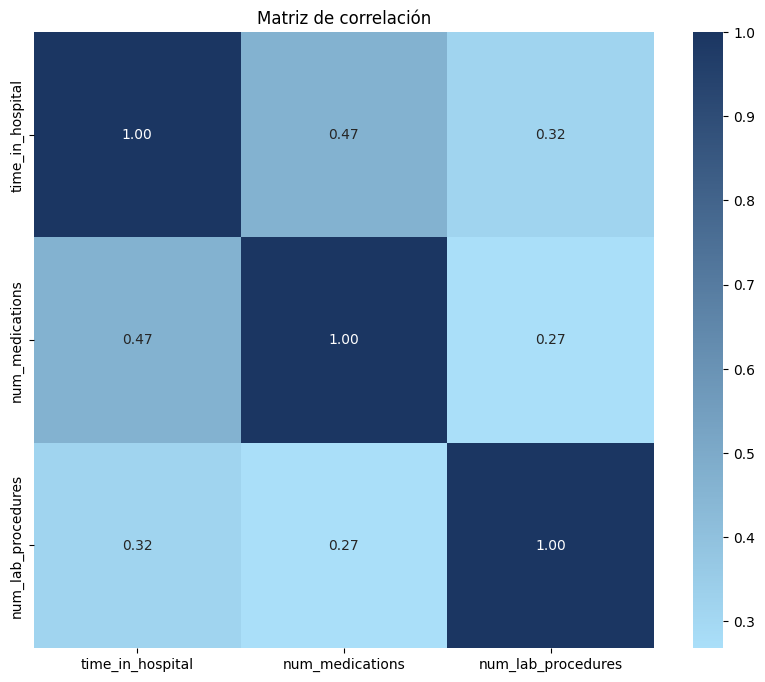

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(10,8))

corr = df[numeric_cols].astype(float).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap
)

plt.title('Matriz de correlación')

plt.savefig('/content/1.matrix_corr.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretaciones iniciales**

**Tendencias y patrones básicos**

*   La mayoría de los pacientes presenta estancias hospitalarias cortas, concentradas entre 1 y 7 días.
*   El número de medicamentos administrados muestra una alta variabilidad, con concentración en valores intermedios pero presencia de casos con valores elevados.
*   Se observan valores atípicos en variables como número de medicamentos y procedimientos, indicando casos clínicos más complejos o poco frecuentes.
*   Las variables relacionadas con el uso previo del sistema de salud (visitas ambulatorias, hospitalizaciones y emergencias) evidencian que existe un grupo de pacientes con alta recurrencia en los servicios médicos.





**Observaciones sobre la base de datos**

*   Algunas variables contienen valores faltantes representados como "?", lo que requiere procesos de limpieza e imputación.
*   Varias variables son categóricas codificadas (como los rangos de edad), lo que limita la precisión de ciertos análisis cuantitativos.
*   Existen valores atípicos en variables clave, lo que puede afectar medidas estadísticas como la media.
*   No todas las variables permiten establecer relaciones causales, ya que el dataset es observacional.
*   La información corresponde a hospitales de Estados Unidos entre 1999 y 2008, lo que puede limitar la generalización a otros contextos o periodos.









**Hipótesis iniciales**



*   Un mayor número de medicamentos administrados está asociado con un mayor tiempo de hospitalización.
*   Los pacientes con mayor número de procedimientos de laboratorio tienden a presentar estancias hospitalarias más largas.
*   Podrían existir diferencias en el uso de servicios o en la estancia hospitalaria según variables demográficas como edad, género o raza.









## Uso de medicamentos clave

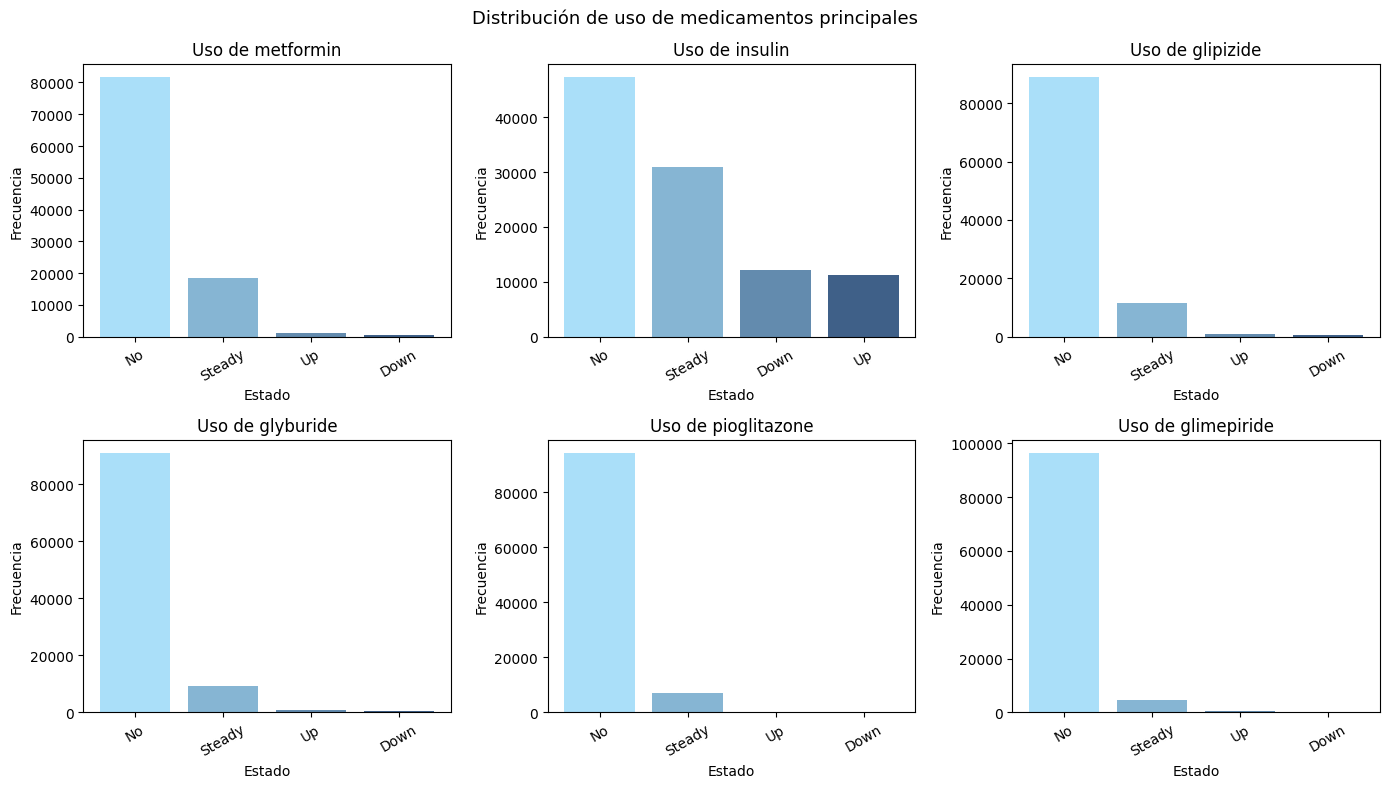

In [ ]:
meds = [
    'metformin',
    'insulin',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'glimepiride'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, med in zip(axes.flatten(), meds):

    counts = df[med].value_counts()

    ax.bar(
        counts.index,
        counts.values,
        color=colors[:len(counts)]
    )

    ax.set_title(f'Uso de {med}')
    ax.set_xlabel('Estado')
    ax.set_ylabel('Frecuencia')

    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Distribución de uso de medicamentos principales',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    '/content/2.multi_medicamentos.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Unidad 4. Imputación, escalamiento y transformación de Datos

Esta fase prepara los datos para el análisis multivariado y el clustering, abordando tres dimensiones: (1) estrategia de imputación para valores faltantes, (2) codificación de variables categóricas, y (3) escalado de variables numéricas.

In [ ]:
# Imputación de valores faltantes

total = len(df)
faltantes_pct = (df.isnull().sum() / total * 100).sort_values(ascending=False)
faltantes_pct = faltantes_pct[faltantes_pct > 0]

print('\nPorcentaje de valores faltantes por variable:')
for col, pct in faltantes_pct.items():
    estrategia = (
        'Excluir del análisis (>80% faltante)' if pct > 80 else
        'Excluir o categoría Desconocido' if pct > 40 else
        'Imputar con moda'
    )
    print(f'  {col:<22} {pct:5.1f}%  {estrategia}')

# Aplicar estrategias
df_clean = df.copy()

# 1. Variables con >80% faltante: excluir
vars_excluir = ['weight', 'max_glu_serum', 'A1Cresult']
print(f'\n1. Excluidas (>80% faltante): {vars_excluir}')

# 2. payer_code y medical_specialty: imputar como categoría
for col in ['payer_code', 'medical_specialty']:
    n = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna('Desconocido')
    print(f'2. {col}: {n:,} faltantes - imputados como Desconocido')

# 3. race: 2.2% faltante - moda
moda_race = df_clean['race'].mode()[0]
n_race = df_clean['race'].isnull().sum()
df_clean['race'] = df_clean['race'].fillna(moda_race)
print(f'3. race: {n_race:,} faltantes - imputados con moda ({moda_race!r})')

# 4. diag_1/2/3: <2% faltante - eliminar filas
n_diag = df_clean[['diag_1','diag_2','diag_3']].isnull().any(axis=1).sum()
df_clean.dropna(subset=['diag_1','diag_2','diag_3'], inplace=True)
print(f'4. diag_1/2/3: {n_diag:,} filas con faltantes - eliminadas')

print(f'\nRegistros antes: {total:,}')
print(f'Registros después: {len(df_clean):,}')
print(f'Pérdida: {total-len(df_clean):,} ({(total-len(df_clean))/total*100:.2f}%)')

faltantes_post = df_clean[[c for c in df_clean.columns
                            if c not in vars_excluir]].isnull().sum()
print('\nFaltantes restantes (sin vars descartadas):')
print(faltantes_post[faltantes_post > 0]
      if faltantes_post.any() else '  OK - Ninguno')


Porcentaje de valores faltantes por variable:
  weight                  96.9%  Excluir del análisis (>80% faltante)
  max_glu_serum           94.7%  Excluir del análisis (>80% faltante)
  A1Cresult               83.3%  Excluir del análisis (>80% faltante)
  medical_specialty       49.1%  Excluir o categoría Desconocido
  payer_code              39.6%  Imputar con moda
  race                     2.2%  Imputar con moda
  diag_3                   1.4%  Imputar con moda
  diag_2                   0.4%  Imputar con moda
  diag_1                   0.0%  Imputar con moda

1. Excluidas (>80% faltante): ['weight', 'max_glu_serum', 'A1Cresult']
2. payer_code: 40,256 faltantes - imputados como Desconocido
2. medical_specialty: 49,949 faltantes - imputados como Desconocido
3. race: 2,273 faltantes - imputados con moda ('Caucasian')
4. diag_1/2/3: 1,522 filas con faltantes - eliminadas

Registros antes: 101,766
Registros después: 100,244
Pérdida: 1,522 (1.50%)

Faltantes restantes (sin vars descar

In [ ]:
# Codificación de variables catergóricas


# Edad: ordinal (rangos tienen orden natural)
orden_edad = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2,  '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6,  '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
df_clean['age_num'] = df_clean['age'].map(orden_edad)
print('age - age_num (ordinal 0-9): OK')

# Readmisión: ordinal (urgencia creciente)
df_clean['readmitted_num'] = df_clean['readmitted'].map(
    {'NO': 0, '>30': 1, '<30': 2})
print('readmitted - readmitted_num (ordinal 0-2): OK')

# Género: binario
df_clean_g = df_clean[df_clean['gender'].isin(['Male','Female'])].copy()
df_clean_g['gender_num'] = df_clean_g['gender'].map({'Male': 0, 'Female': 1})
print('gender - gender_num (0=Male, 1=Female): OK')

# Insulina: ordinal (intensidad de prescripción)
df_clean_g['insulin_num'] = df_clean_g['insulin'].map(
    {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3})
print('insulin - insulin_num (ordinal 0-3): OK')

# Resumen de codificación
encoding_summary = pd.DataFrame({
    'Variable original': ['age', 'gender', 'readmitted', 'insulin'],
    'Variable nueva': ['age_num', 'gender_num', 'readmitted_num', 'insulin_num'],
    'Tipo': ['Ordinal', 'Binaria', 'Ordinal', 'Ordinal'],
    'Rango': ['0-9', '0-1', '0-2', '0-3'],
    'Justificación': [
        'Rangos etarios tienen orden natural',
        'Dos categorías simétricas',
        'Urgencia de reingreso es ordenable',
        'Intensidad de tratamiento es ordenable'
    ]
})
print('\nResumen de codificación:')
print(encoding_summary.to_string(index=False))

age - age_num (ordinal 0-9): OK
readmitted - readmitted_num (ordinal 0-2): OK
gender - gender_num (0=Male, 1=Female): OK
insulin - insulin_num (ordinal 0-3): OK

Resumen de codificación:
Variable original Variable nueva    Tipo Rango                          Justificación
              age        age_num Ordinal   0-9    Rangos etarios tienen orden natural
           gender     gender_num Binaria   0-1              Dos categorías simétricas
       readmitted readmitted_num Ordinal   0-2     Urgencia de reingreso es ordenable
          insulin    insulin_num Ordinal   0-3 Intensidad de tratamiento es ordenable


Justificacion: K-Means minimiza distancias euclidianas.
Variables con mayor rango dominan el calculo sin escalado.
StandardScaler transforma a media=0 y desv.std=1.

Registros disponibles para escalado: 100,241


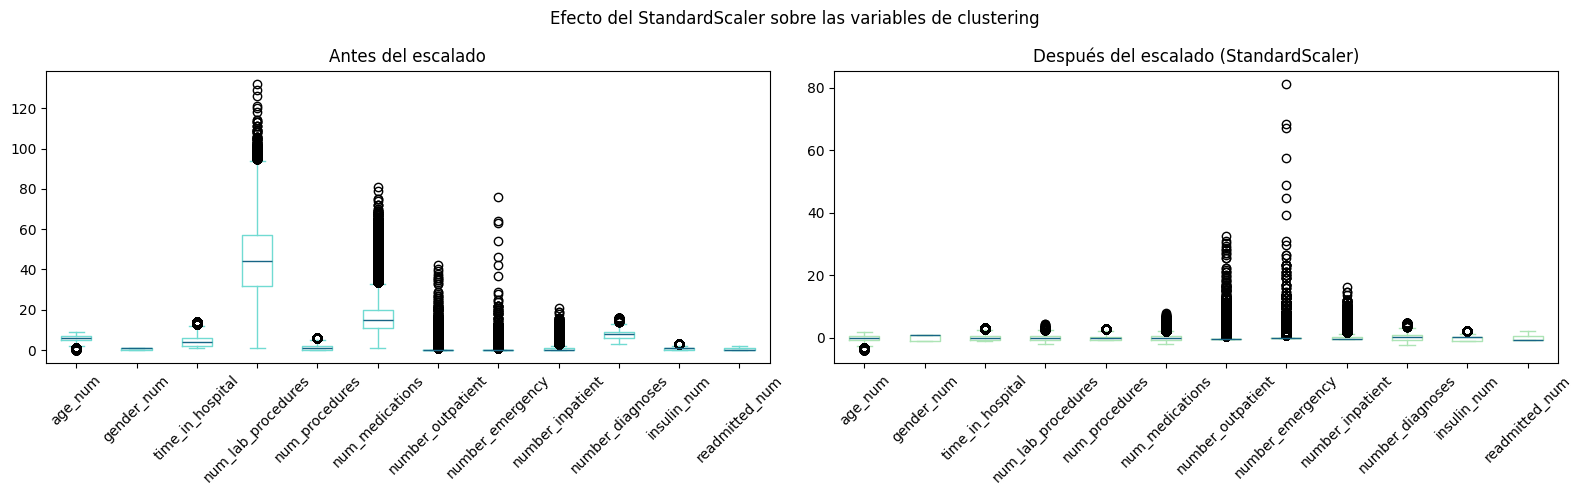


Estadísticas post-escalado (media ~0, std ~1):
      age_num  gender_num  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses  insulin_num  readmitted_num
mean      0.0         0.0              -0.0                -0.0             0.0             -0.0                0.0               0.0              -0.0               0.0          0.0             0.0
std       1.0         1.0               1.0                 1.0             1.0              1.0                1.0               1.0               1.0               1.0          1.0             1.0


In [ ]:
# Escalamiento

from sklearn.preprocessing import StandardScaler


print('Justificacion: K-Means minimiza distancias euclidianas.')
print('Variables con mayor rango dominan el calculo sin escalado.')
print('StandardScaler transforma a media=0 y desv.std=1.\n')

vars_clustering_u4 = [
    'age_num', 'gender_num', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses',
    'insulin_num', 'readmitted_num'
]

df_model = df_clean_g[vars_clustering_u4].dropna()
print(f'Registros disponibles para escalado: {len(df_model):,}')

scaler_u4 = StandardScaler()
X_scaled_u4 = scaler_u4.fit_transform(df_model)

# Visualizar efecto del escalado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_model.plot(kind='box', ax=axes[0],
              color={'boxes': '#71dbd2', 'medians': '#176585',
                     'whiskers': '#71dbd2', 'caps': '#71dbd2'})
axes[0].set_title('Antes del escalado')
axes[0].tick_params(axis='x', rotation=45)

pd.DataFrame(X_scaled_u4, columns=vars_clustering_u4).plot(
    kind='box', ax=axes[1],
    color={'boxes': '#ade4b5', 'medians': '#176585',
           'whiskers': '#ade4b5', 'caps': '#ade4b5'})
axes[1].set_title('Después del escalado (StandardScaler)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto del StandardScaler sobre las variables de clustering', fontsize=12)
plt.tight_layout()
plt.savefig('/content/4.escalado_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEstadísticas post-escalado (media ~0, std ~1):')
print(pd.DataFrame(X_scaled_u4, columns=vars_clustering_u4)
      .describe().loc[['mean','std']].round(4).to_string())

## Preprocesamiento para clústeres

Antes de aplicar PCA y K-Means, es necesario:
1. Seleccionar las variables relevantes para la identificación de perfiles.
2. Codificar las variables categóricas.
3. Escalar las variables numéricas (K-Means es sensible a la escala).

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

colors = ["#71dbd2", "#ade4b5", "#d0eaa3", "#fff18c"]

#  3.1 Selección de variables
# Usamos variables con información clínica, demográfica y de uso de servicios.
# Excluimos IDs, diagnósticos ICD-9 crudos y medicamentos individuales
# (demasiado granulares y mayoritariamente con valor "No").

vars_clustering = [
    'age',                  # demográfica ordinal
    'gender',               # demográfica categórica
    'time_in_hospital',     # uso hospitalario
    'num_lab_procedures',   # intensidad diagnóstica
    'num_procedures',       # intervenciones
    'num_medications',      # carga farmacológica
    'number_outpatient',    # historial ambulatorio
    'number_emergency',     # historial urgencias
    'number_inpatient',     # historial hospitalizaciones
    'number_diagnoses',     # complejidad clínica
    'insulin',              # medicamento más frecuente
    'readmitted'            # resultado de interés
]

df_cluster = df[vars_clustering].copy()

print("Forma del subconjunto:", df_cluster.shape)
print("\nValores faltantes por variable:")
print(df_cluster.isnull().sum())

#  3.2 Tratamiento de valores faltantes
# 'gender' puede tener 'Unknown/Invalid' → se reemplaza por moda
df_cluster['gender'] = df_cluster['gender'].replace('Unknown/Invalid', np.nan)
df_cluster['gender'].fillna(df_cluster['gender'].mode()[0], inplace=True)

# Eliminamos filas con NaN restantes (son minoría)
df_cluster.dropna(inplace=True)
print(f"\nRegistros tras limpieza: {df_cluster.shape[0]}")

#  3.3 Codificación de variables categóricas

# Edad: variable ordinal  mapeo numérico
orden_edad = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2,  '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6,  '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
df_cluster['age'] = df_cluster['age'].map(orden_edad)

# Género: binario
df_cluster['gender'] = df_cluster['gender'].map({'Male': 0, 'Female': 1})

# Readmisión: ordinal (sin reingreso < reingreso tardío < reingreso temprano)
df_cluster['readmitted'] = df_cluster['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

# Insulina: ordinal (intensidad de prescripción)
df_cluster['insulin'] = df_cluster['insulin'].map({
    'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3
})

print("\nTipos tras codificación:")
print(df_cluster.dtypes)

# 3.4 Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("\nEscalado completado. Shape:", X_scaled.shape)


Forma del subconjunto: (101766, 12)

Valores faltantes por variable:
age                   0
gender                0
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
insulin               0
readmitted            0
dtype: int64

Registros tras limpieza: 101766

Tipos tras codificación:
age                   int64
gender                int64
time_in_hospital      int64
num_lab_procedures    int64
num_procedures        int64
num_medications       int64
number_outpatient     int64
number_emergency      int64
number_inpatient      int64
number_diagnoses      int64
insulin               int64
readmitted            int64
dtype: object

Escalado completado. Shape: (101766, 12)


/tmp/ipykernel_8215/1920819802.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster['gender'].fillna(df_cluster['gender'].mode()[0], inplace=True)


## Reducción de la dimensionalidad usando PCA

PCA transforma las 12 variables originales en componentes no correlacionados,
ordenados por varianza explicada. Esto permite:
- Eliminar redundancia entre variables correlacionadas.
- Proyectar los datos en 2D para visualización.
- Estabilizar el clustering al reducir el ruido dimensional.


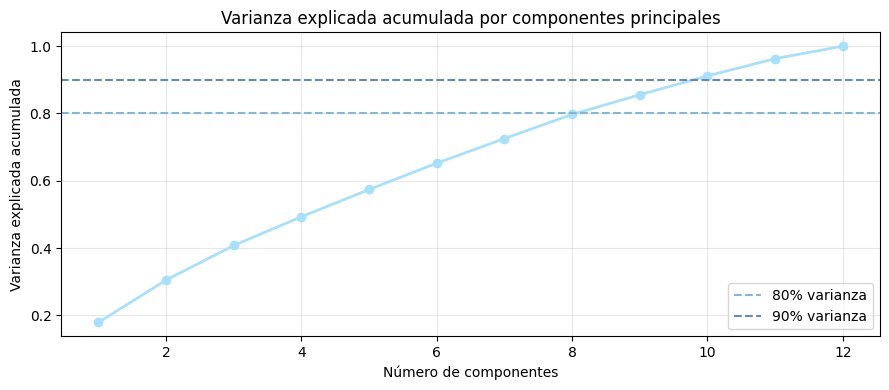

Componentes necesarios para explicar ≥80% de la varianza: 9

Varianza explicada por cada componente:
  PC1: 0.179 (17.9%)
  PC2: 0.126 (12.6%)
  PC3: 0.103 (10.3%)
  PC4: 0.085 (8.5%)
  PC5: 0.081 (8.1%)
  PC6: 0.078 (7.8%)
  PC7: 0.073 (7.3%)
  PC8: 0.072 (7.2%)
  PC9: 0.058 (5.8%)


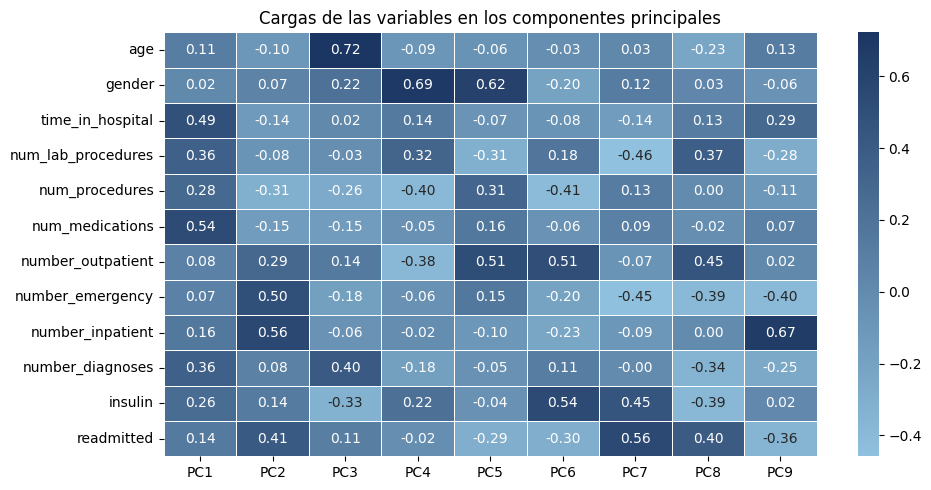

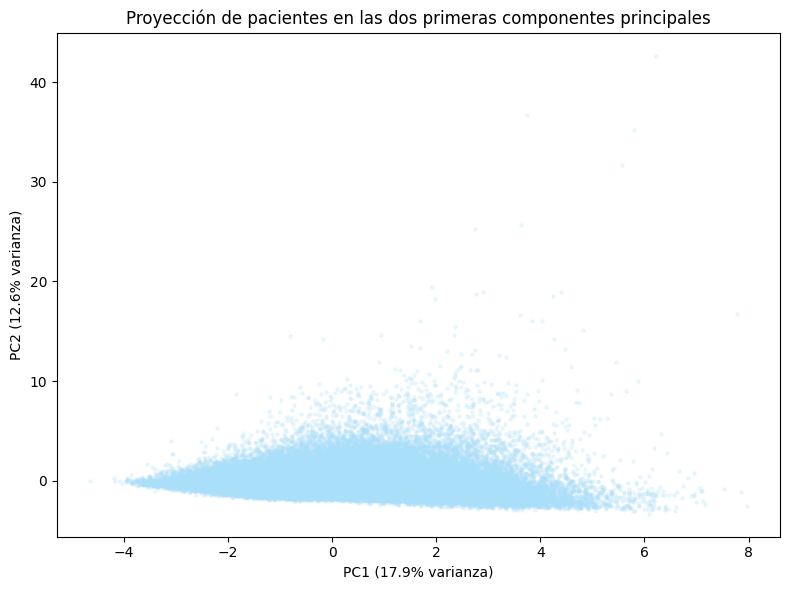

In [ ]:
colors = ["#aadff9", "#86b5d3", "#638bae", "#3f6088", "#1b3662"]
sns.set_palette(colors)

from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

# 4.1 Varianza explicada por componente
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
         marker='o', color='#aadff9', linewidth=2, markersize=6)
plt.axhline(y=0.80, color='#86b5d3', linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='#638bae', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por componentes principales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/3.pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# Número de componentes para el 80% de varianza
n_componentes = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Componentes necesarios para explicar ≥80% de la varianza: {n_componentes}")

# 4.2 Aplicar PCA con n componentes
pca = PCA(n_components=n_componentes, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVarianza explicada por cada componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f} ({v*100:.1f}%)")

# 4.3 Cargas de los componentes (interpretabilidad)
# 4.3 Cargas de los componentes (interpretabilidad)
vars_clustering = [
    'age', 'gender', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses',
    'insulin', 'readmitted'
]

loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_clustering,
    columns=[f'PC{i+1}' for i in range(n_componentes)]
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    linewidths=0.5
)
plt.title('Cargas de las variables en los componentes principales')
plt.tight_layout()
plt.savefig('/content/3.pca_cargas.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.4 Visualización 2D (PC1 vs PC2)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            alpha=0.2, s=5, color='#aadff9')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección de pacientes en las dos primeras componentes principales')
plt.tight_layout()
plt.savefig('/content/3.pca_proyeccion2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Clustering con K-means

K-Means particiona los pacientes en k grupos minimizando la varianza intra-clúster.
Se aplica sobre los componentes principales para mayor estabilidad.

Para elegir k se usan dos criterios complementarios:
- Método del codo
- Índice de silueta

k=2 → Inercia: 906024 | Silueta: 0.1558
k=3 → Inercia: 834052 | Silueta: 0.1402
k=4 → Inercia: 769856 | Silueta: 0.1138
k=5 → Inercia: 717921 | Silueta: 0.1219
k=6 → Inercia: 673682 | Silueta: 0.1288
k=7 → Inercia: 639760 | Silueta: 0.1293
k=8 → Inercia: 612679 | Silueta: 0.1275


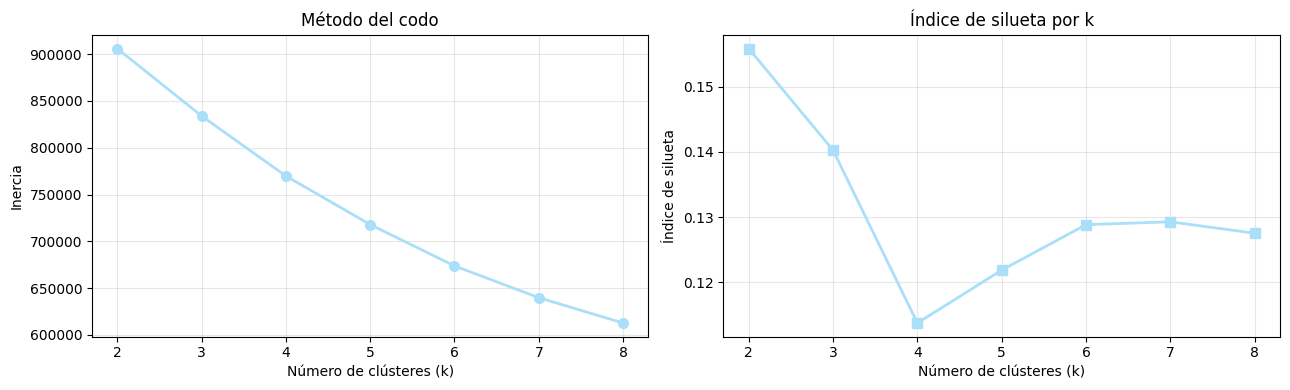


K óptimo seleccionado: 2 (silueta = 0.1558)

Distribución de pacientes por clúster:
cluster
0    62111
1    39655
Name: count, dtype: int64


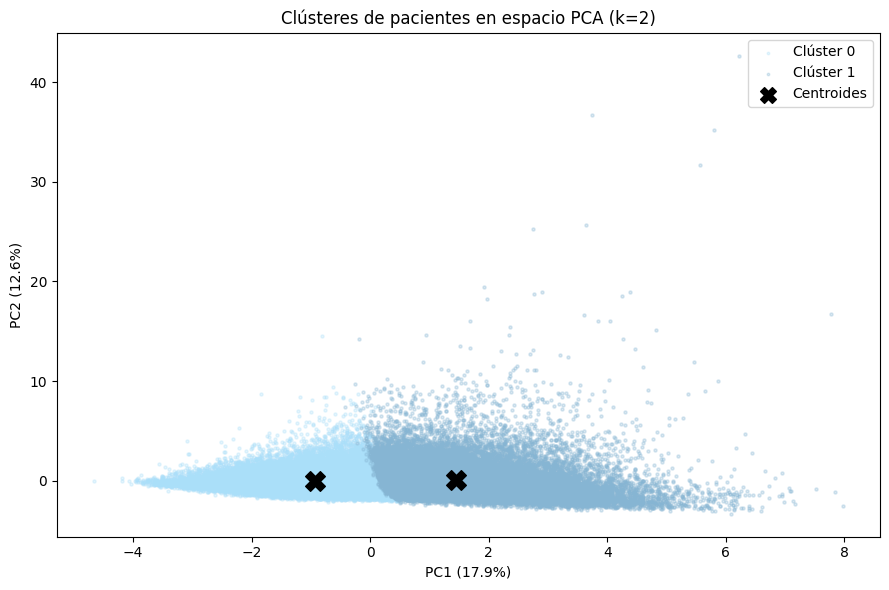

In [ ]:
#  5.1 Método del codo + Silueta
inercias = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_pca, etiquetas, sample_size=10000, random_state=42))
    print(f"k={k} → Inercia: {km.inertia_:.0f} | Silueta: {siluetas[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Codo
axes[0].plot(rango_k, inercias, marker='o', color="#aadff9", linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

# Silueta
axes[1].plot(rango_k, siluetas, marker='s', color="#aadff9", linewidth=2, markersize=7)
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Índice de silueta')
axes[1].set_title('Índice de silueta por k')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/4.kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.2 Ajuste del modelo final
# Selecciona el k con mayor índice de silueta
k_optimo = list(rango_k)[np.argmax(siluetas)]
print(f"\nK óptimo seleccionado: {k_optimo} (silueta = {max(siluetas):.4f})")

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_pca)

print("\nDistribución de pacientes por clúster:")
print(df_cluster['cluster'].value_counts().sort_index())

# 5.3 Visualización de clústeres en espacio PCA
cluster_colors = ["#aadff9", "#86b5d3", "#638bae", "#3f6088", "#1b3662"]

plt.figure(figsize=(9, 6))
for c in range(k_optimo):
    mask = df_cluster['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=5, alpha=0.3, label=f'Clúster {c}',
                color=cluster_colors[c])

# Centroides
centroides_pca = km_final.cluster_centers_
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker='X', c='black', zorder=5, label='Centroides')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Clústeres de pacientes en espacio PCA (k={k_optimo})')
plt.legend(markerscale=0.8)
plt.tight_layout()
plt.savefig('/content/4.kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretación Clínica de los Perfiles

A partir del análisis K-Means con **k=2** (seleccionado por mayor índice de silueta = 0.1558 sobre 9 componentes PCA), se identificaron dos perfiles diferenciados de pacientes diabéticos hospitalizados:


### Clúster 0. Paciente diabético estable de baja complejidad
**62.111 pacientes (61% de la muestra)**

| Característica | Valor medio |
|----------------|:-----------:|
| Edad | ≈ [60-70) años |
| % femenino | 52% |
| Días de hospitalización | **2.99 días** |
| Procedimientos de laboratorio | 36.2 |
| Medicamentos | **12.2** |
| Hospitalizaciones previas | 0.39 |
| Visitas a urgencias previas | 0.12 |
| Número de diagnósticos | 6.81 |
| Índice de readmisión | 0.46 (mayoritariamente sin readmisión) |

**Perfil clínico**: paciente de 60–70 años con diabetes de manejo relativamente controlado, estancia corta, baja carga farmacológica y escaso historial de urgencias o reingresos. Representa el grupo de menor complejidad y menor demanda de recursos hospitalarios.


### Clúster 1. Paciente diabético de alta complejidad y alta utilización
**39.655 pacientes (39% de la muestra)**

| Característica | Valor medio |
|----------------|:-----------:|
| Edad | ≈ [60-70) a [70-80) años |
| % femenino | 56% |
| Días de hospitalización | **6.60 días** (2.2× más que Clúster 0) |
| Procedimientos de laboratorio | 53.8 (48% más) |
| Medicamentos | **22.0** (81% más) |
| Hospitalizaciones previas | 1.02 (2.6× más) |
| Visitas a urgencias previas | 0.31 (2.6× más) |
| Número de diagnósticos | 8.39 |
| Índice de readmisión | 0.75 (mayor tendencia a readmisión >30 días) |

**Perfil clínico**: paciente mayor con diabetes complicada por comorbilidades múltiples, estancia prolongada, alta carga de medicamentos e historial frecuente de reingresos y urgencias. Representa el grupo de mayor demanda de recursos y mayor riesgo clínico.


### Implicaciones operativas

- Los pacientes del **Clúster 1** son candidatos prioritarios para **programas de gestión de enfermedades crónicas** y seguimiento post-egreso intensivo, dado su alta tasa de reingresos.
- Los del **Clúster 0** podrían beneficiarse de **protocolos de atención ambulatoria** que prevengan hospitalizaciones innecesarias.
- La diferencia de **3.6 días en la estancia media** tiene implicaciones directas en costos hospitalarios: intervenciones tempranas en el Clúster 1 representan el mayor potencial de optimización.

> **Nota metodológica**: el índice de silueta de 0.1558 indica una separación moderada, esperable en datos clínicos de alta dimensionalidad. Es consistente con la literatura sobre clustering en registros de pacientes diabéticos.

Resumen de perfiles por clúster:
         n_pacientes  edad_media  pct_femenino  dias_hospitalizacion  lab_procedures  medicamentos  hospitalizaciones_previas  emergencias_previas  n_diagnosticos  readmision_media
cluster                                                                                                                                                                             
0              62111        5.97          0.52                  2.99           36.23         12.19                       0.39                 0.12            6.81              0.46
1              39655        6.29          0.56                  6.60           53.84         22.03                       1.02                 0.31            8.39              0.75


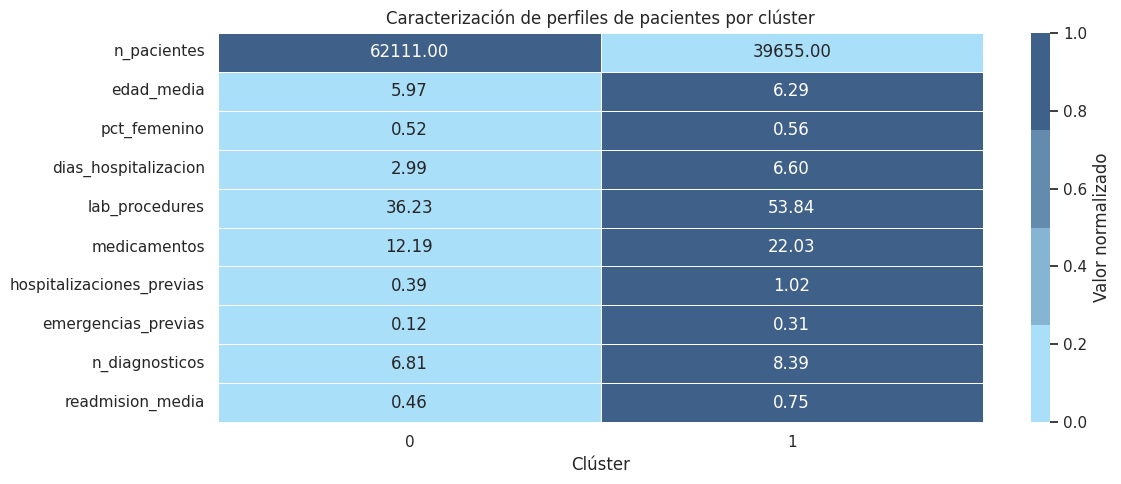

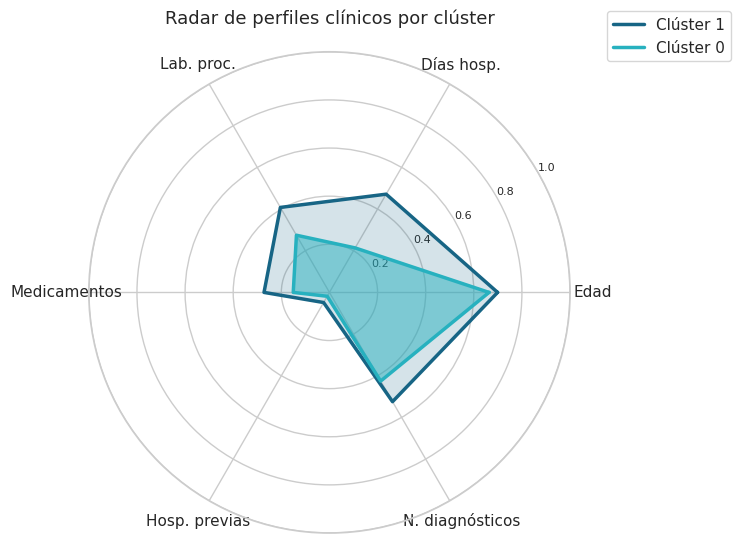

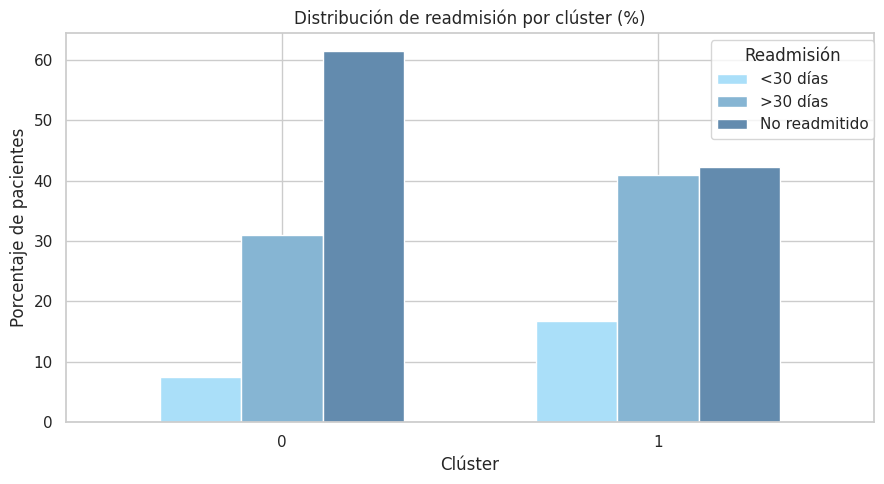

In [ ]:
#Caracterización e interpretación de los clústeres
#Cada clúster representa un perfil de paciente con características compartidas.
#A continuación se analiza cada perfil en términos de sus variables clave.

colors = ["#aadff9", "#86b5d3", "#638bae", "#3f6088"]

sns.set_theme(style="whitegrid")
sns.set_palette(sns.color_palette(colors))
cluster_colors = colors

#  6.1 Estadísticas descriptivas por clúster
resumen = df_cluster.groupby('cluster').agg(
    n_pacientes=('cluster', 'count'),
    edad_media=('age', 'mean'),
    pct_femenino=('gender', 'mean'),
    dias_hospitalizacion=('time_in_hospital', 'mean'),
    lab_procedures=('num_lab_procedures', 'mean'),
    medicamentos=('num_medications', 'mean'),
    hospitalizaciones_previas=('number_inpatient', 'mean'),
    emergencias_previas=('number_emergency', 'mean'),
    n_diagnosticos=('number_diagnoses', 'mean'),
    readmision_media=('readmitted', 'mean')
).round(2)

print("Resumen de perfiles por clúster:")
print(resumen.to_string())

# 6.2 Heatmap de perfiles
# Normalizar para comparar en la misma escala
resumen_norm = (resumen - resumen.min()) / (resumen.max() - resumen.min())

plt.figure(figsize=(12, 5))
sns.heatmap(resumen_norm.T, annot=resumen.T, fmt='.2f',
            cmap=sns.color_palette(colors, as_cmap=True),
            linewidths=0.5, cbar_kws={'label': 'Valor normalizado'})
plt.title('Caracterización de perfiles de pacientes por clúster')
plt.xlabel('Clúster')
plt.tight_layout()
plt.savefig('/content/5.perfiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 6.3 Radar chart por clúster
radar_vars = ['edad_media', 'dias_hospitalizacion', 'lab_procedures',
              'medicamentos', 'hospitalizaciones_previas', 'n_diagnosticos']

radar_vars_orig = ['age', 'time_in_hospital', 'num_lab_procedures',
                   'num_medications', 'number_inpatient', 'number_diagnoses']

etiquetas_radar = ['Edad', 'Días hosp.', 'Lab. proc.',
                   'Medicamentos', 'Hosp. previas', 'N. diagnósticos']

max_orig = df_cluster[radar_vars_orig].max()

valores_radar = pd.DataFrame({
    var_r: resumen[var_s] / max_orig[var_o]
    for var_r, var_s, var_o in zip(
        etiquetas_radar, radar_vars, radar_vars_orig
    )
}, index=resumen.index)

N = len(etiquetas_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

radar_colors = {
    0: {"line": "#27b1bf", "fill": "#27b1bf"},
    1: {"line": "#176585", "fill": "#176585"},
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx in [1, 0]:
    row = valores_radar.loc[idx]
    vals = row.tolist() + row.tolist()[:1]
    c = radar_colors[idx]
    alpha_fill = 0.18 if idx == 1 else 0.50

    ax.plot(angulos, vals, linewidth=2.5,
            color=c["line"], label=f'Clúster {idx}')
    ax.fill(angulos, vals, alpha=alpha_fill, color=c["fill"])

ax.set_thetagrids(np.degrees(angulos[:-1]), etiquetas_radar, fontsize=11)
ax.set_rlabel_position(30)
ax.set_ylim(0, 1)
ax.yaxis.set_tick_params(labelsize=8)
ax.set_title('Radar de perfiles clínicos por clúster', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('/content/5.perfiles_radar.png', dpi=150, bbox_inches='tight')
plt.show()


# 6.4 Distribución de readmisión por clúster
readmision_labels = {0: 'No readmitido', 1: '>30 días', 2: '<30 días'}
df_cluster['readmitted_label'] = df_cluster['readmitted'].map(readmision_labels)

plt.figure(figsize=(9, 5))
readm_pct = (df_cluster.groupby(['cluster', 'readmitted_label'])
             .size()
             .unstack(fill_value=0)
             .apply(lambda x: x / x.sum() * 100, axis=1))

readm_pct.plot(kind='bar', ax=plt.gca(),
               color=["#aadff9", "#86b5d3", "#638bae", "#3f6088", "#1b3662"],
               edgecolor='white', width=0.65)
plt.title('Distribución de readmisión por clúster (%)')
plt.xlabel('Clúster')
plt.ylabel('Porcentaje de pacientes')
plt.xticks(rotation=0)
plt.legend(title='Readmisión', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('/content/5.perfiles_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

## **Resumen**

In [ ]:
print("Análisis de perfiles completado.")
print(f"\nResumen final:")
print(f"  - Pacientes analizados: {len(df_cluster):,}")
print(f"  - Componentes PCA: {n_componentes} (≥80% varianza)")
print(f"  - Clústeres identificados: {k_optimo}")
print(f"  - Índice de silueta final: {max(siluetas):.4f}")

Análisis de perfiles completado.

Resumen final:
  - Pacientes analizados: 101,766
  - Componentes PCA: 9 (≥80% varianza)
  - Clústeres identificados: 2
  - Índice de silueta final: 0.1558


### **Referencias**

**Dataset**: Diabetes 130-US Hospitals Dataset

**Repositorio**: UCI Machine Learning Repository

**Autores**: Beata Strack et al. (2014)

**Descripción**: conjunto de datos clínicos que recopila información de pacientes diabéticos hospitalizados en 130 hospitales de Estados Unidos entre 1999 y 2008, incluyendo variables sobre admisiones, procedimientos médicos, medicamentos, tiempo de hospitalización y readmisiones.

**Repositorios usados**:

https://github.com/mariabda2/intro_data_2026?authuser=1